# Credit Risk Modelling — Part 4.8: Best Model Deep-Dive
---
**Objective:** Thoroughly analyse the winning model from Part 4.7 across every dimension that matters in credit risk.

This notebook goes beyond basic metrics — we examine the model from a **business deployment perspective**:
- How does performance change at different decision thresholds?
- Which features are actually driving predictions?
- How trustworthy are the predicted probabilities?
- How much business value does this model deliver?

**Steps:**
1. Load best model and data
2. Threshold analysis — precision, recall, F1 across all thresholds
3. Business value curve — expected loss reduction at each threshold
4. Feature importance — top features, family breakdown, missingness flags
5. Partial dependence — how does each top feature affect default probability?
6. Score distribution deep-dive — separation quality
7. Calibration analysis — are probabilities trustworthy?
8. Default capture curve — business lift analysis
9. Error analysis — who does the model get wrong?
10. Final model card

## 1 — Imports & Load Best Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, warnings, re
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import partial_dependence

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

# Load everything
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")
results        = joblib.load("results_so_far.pkl")
feature_cols   = meta["feature_cols_final"]

with open("model_selection.json") as f:
    selection = json.load(f)

best_name   = selection["best_model_name"]
best_result = results[best_name]
best_model  = best_result["model"]
best_proba  = best_result["proba_test"]
best_color  = best_result["color"]
opt_thresh  = best_result["opt_thresh"]

print(f"Best model      : {best_name}")
print(f"Test AUC        : {best_result['test_auc']:.4f}")
print(f"Test AP         : {best_result['test_ap']:.4f}")
print(f"KS Statistic    : {best_result['ks']:.4f}")
print(f"Gini            : {best_result['gini']:.4f}")
print(f"CV AUC          : {best_result['cv_mean']:.4f} +/- {best_result['cv_std']:.4f}")
print(f"Opt Threshold   : {opt_thresh:.4f}")
print("✓ Loaded")

Best model      : Logistic Regression
Test AUC        : 0.8575
Test AP         : 0.2397
KS Statistic    : 0.5938
Gini            : 0.7149
CV AUC          : 0.8465 +/- 0.0037
Opt Threshold   : 0.5463
✓ Loaded


---
## 2 — Threshold Analysis

The optimal threshold from Youden's J maximises `TPR - FPR`.  
But in credit risk, the **business cost** of a missed default (FN) is often much higher  
than the cost of incorrectly rejecting a safe customer (FP).

We plot precision, recall, and F1 across all thresholds so you can  
choose the operating point that fits your risk appetite.

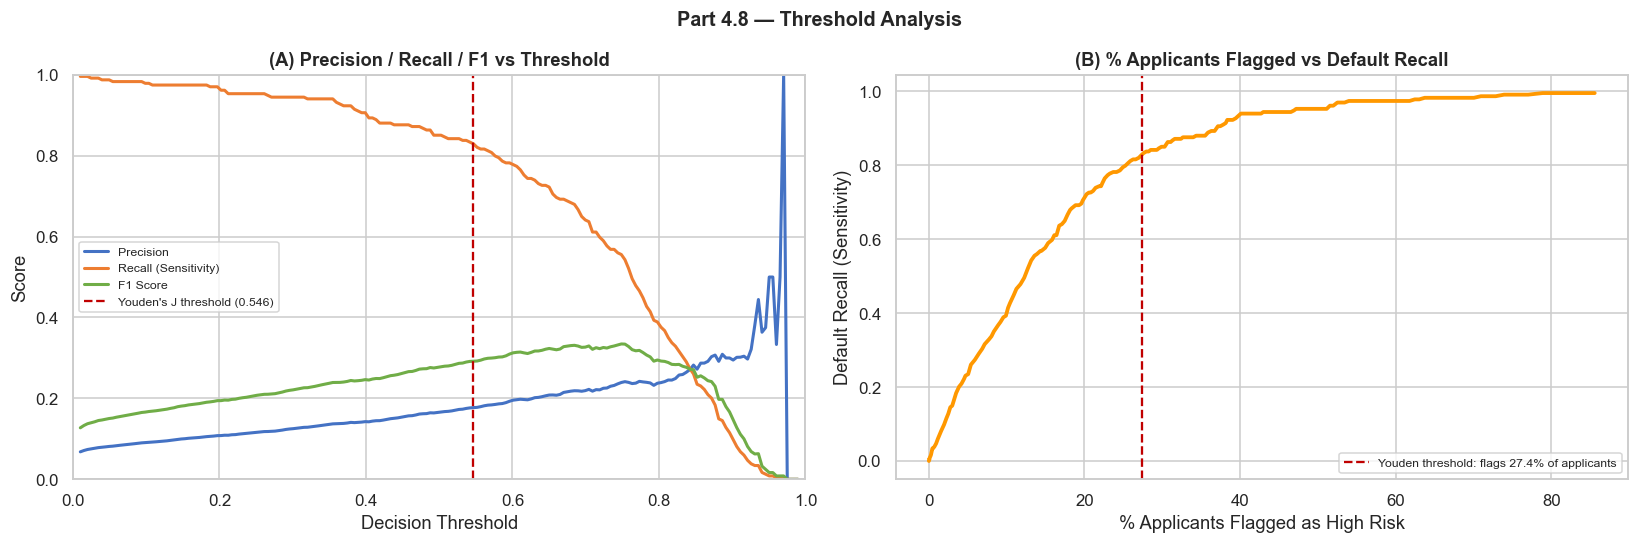

Key operating points:
  Threshold     Precision     Recall       F1    Flag%
-------------------------------------------------------
  0.100             0.091      0.979    0.166    62.9%
  0.150             0.100      0.974    0.181    57.0%
  0.200             0.108      0.966    0.195    52.1%
  0.546             0.177      0.829    0.292    27.4% <- Youden's J
  0.300             0.125      0.944    0.221    44.1%
  0.400             0.143      0.906    0.247    37.1%
  0.500             0.166      0.850    0.277    30.0%


In [2]:
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, best_proba)
prec_arr, rec_arr, thresh_pr = precision_recall_curve(y_test, best_proba)

# Compute metrics at every threshold
thresholds  = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s, fprs, tprs = [], [], [], [], []

for t in thresholds:
    y_pred = (best_proba >= t).astype(int)
    tp = ((y_pred==1) & (y_test==1)).sum()
    fp = ((y_pred==1) & (y_test==0)).sum()
    fn = ((y_pred==0) & (y_test==1)).sum()
    tn = ((y_pred==0) & (y_test==0)).sum()
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    fpr  = fp/(fp+tn) if (fp+tn) > 0 else 0
    precisions.append(prec); recalls.append(rec)
    f1s.append(f1); fprs.append(fpr); tprs.append(tp/(tp+fn) if (tp+fn)>0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Part 4.8 — Threshold Analysis", fontsize=13, fontweight="bold")

# (A) Precision, Recall, F1 vs threshold
ax = axes[0]
ax.plot(thresholds, precisions, color=BLUE,   lw=2, label="Precision")
ax.plot(thresholds, recalls,    color=ORANGE, lw=2, label="Recall (Sensitivity)")
ax.plot(thresholds, f1s,        color=GREEN,  lw=2, label="F1 Score")
ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.5,
           label=f"Youden's J threshold ({opt_thresh:.3f})")
ax.set_title("(A) Precision / Recall / F1 vs Threshold", fontweight="bold")
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# (B) Volume flagged vs recall
ax = axes[1]
flag_rates = [(best_proba >= t).mean()*100 for t in thresholds]
ax.plot(flag_rates, recalls, color=best_color, lw=2.5)
ax.axvline((best_proba >= opt_thresh).mean()*100, color=RED, linestyle="--", lw=1.5,
           label=f"Youden threshold: flags {(best_proba >= opt_thresh).mean()*100:.1f}% of applicants")
ax.set_title("(B) % Applicants Flagged vs Default Recall", fontweight="bold")
ax.set_xlabel("% Applicants Flagged as High Risk")
ax.set_ylabel("Default Recall (Sensitivity)")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Print key threshold options
print("Key operating points:")
print(f"  {'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Flag%':>8}")
print("-" * 55)
for t in [0.10, 0.15, 0.20, opt_thresh, 0.30, 0.40, 0.50]:
    y_pred = (best_proba >= t).astype(int)
    tp = ((y_pred==1) & (y_test==1)).sum()
    fp = ((y_pred==1) & (y_test==0)).sum()
    fn = ((y_pred==0) & (y_test==1)).sum()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    flag = y_pred.mean()*100
    marker = " <- Youden's J" if abs(t - opt_thresh) < 0.005 else ""
    print(f"  {t:<12.3f} {prec:>10.3f} {rec:>10.3f} {f1:>8.3f} {flag:>7.1f}%{marker}")

---
## 3 — Feature Importance Deep-Dive

We look at feature importances from three angles:
- **Top individual features** — which specific features drive predictions
- **Family-level** — which credit data categories matter most
- **Missingness flags** — do the NaN indicators contribute meaningfully

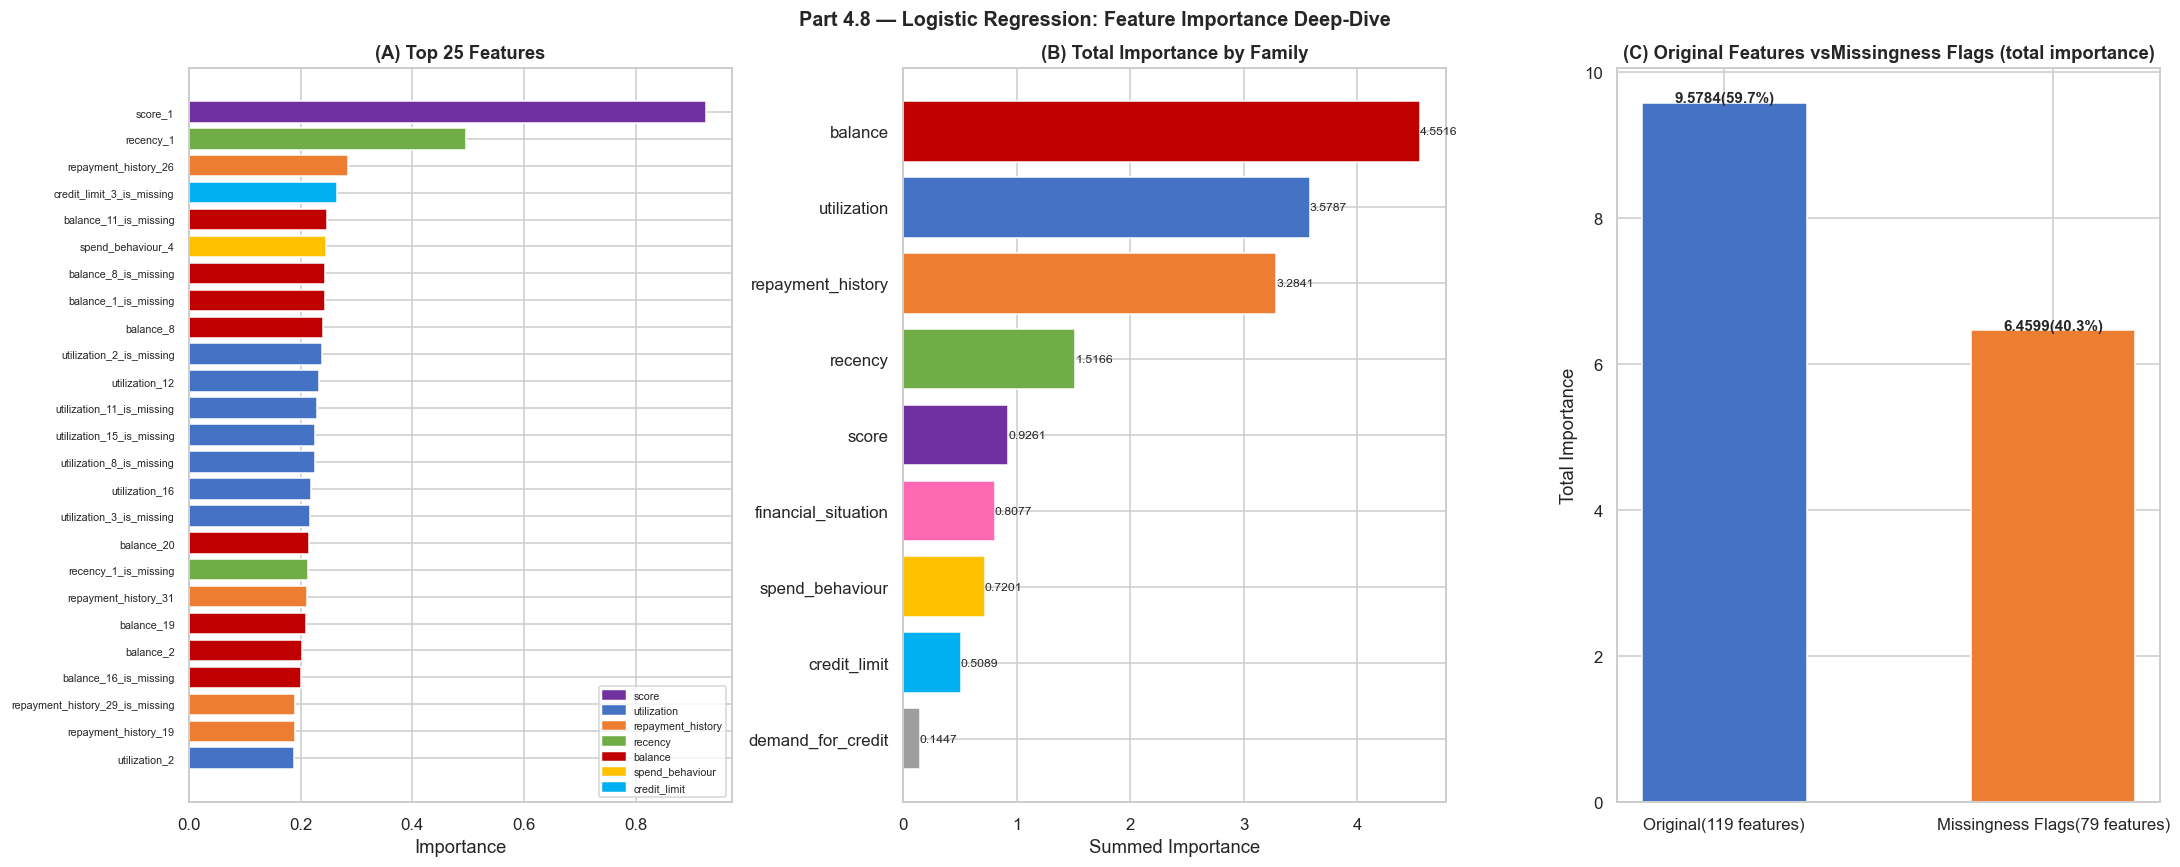

Missingness flags contribute 40.3% of total model importance
  -> Validates Part 3 decision to add 79 missingness indicator columns


In [3]:
def get_family(col):
    m = re.match(r"^([a-z_]+?)_\d+", col)
    return m.group(1) if m else "other"

# Get importances (works for RF and GBM; for LR use abs(coef))
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=feature_cols)
elif hasattr(best_model, "named_steps"):
    clf = best_model.named_steps["clf"]
    fi = pd.Series(np.abs(clf.coef_[0]), index=feature_cols)
else:
    fi = pd.Series(np.zeros(len(feature_cols)), index=feature_cols)

fi_df = pd.DataFrame({
    "feature"    : feature_cols,
    "importance" : fi.values,
    "family"     : [get_family(c) for c in feature_cols],
    "is_flag"    : [c.endswith("_is_missing") for c in feature_cols],
})
fi_df = fi_df.sort_values("importance", ascending=False)

fam_color_map = {
    "score": PURPLE, "utilization": BLUE, "repayment_history": ORANGE,
    "recency": GREEN, "balance": RED, "spend_behaviour": "#FFC000",
    "credit_limit": "#00B0F0", "financial_situation": "#FF69B4",
    "demand_for_credit": GRAY, "other": GRAY
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle(f"Part 4.8 — {best_name}: Feature Importance Deep-Dive",
             fontsize=13, fontweight="bold")

# (A) Top 25 individual features
ax = axes[0]
top25 = fi_df.head(25).sort_values("importance")
bar_colors = [fam_color_map.get(f, GRAY) for f in top25["family"]]
ax.barh(top25["feature"], top25["importance"], color=bar_colors, edgecolor="white")
ax.set_title("(A) Top 25 Features", fontweight="bold")
ax.set_xlabel("Importance")
ax.tick_params(axis="y", labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=f)
                  for f, c in fam_color_map.items()
                  if f in top25["family"].values]
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (B) Total importance by family
ax = axes[1]
fam_imp = fi_df.groupby("family")["importance"].sum().sort_values(ascending=True)
bar_colors_fam = [fam_color_map.get(f, GRAY) for f in fam_imp.index]
ax.barh(fam_imp.index, fam_imp.values, color=bar_colors_fam, edgecolor="white")
ax.set_title("(B) Total Importance by Family", fontweight="bold")
ax.set_xlabel("Summed Importance")
for i, (fam, val) in enumerate(fam_imp.items()):
    ax.text(val+0.0001, i, f"{val:.4f}", va="center", fontsize=8)

# (C) Missingness flags vs original features
ax = axes[2]
flag_imp  = fi_df[fi_df["is_flag"]]["importance"].sum()
orig_imp  = fi_df[~fi_df["is_flag"]]["importance"].sum()
n_flags   = fi_df["is_flag"].sum()
n_orig    = (~fi_df["is_flag"]).sum()
bars = ax.bar(
    [f"Original({n_orig} features)", f"Missingness Flags({n_flags} features)"],
    [orig_imp, flag_imp],
    color=[BLUE, ORANGE], edgecolor="white", width=0.5
)
ax.set_title("(C) Original Features vsMissingness Flags (total importance)",
             fontweight="bold")
ax.set_ylabel("Total Importance")
for bar, val in zip(bars, [orig_imp, flag_imp]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{val:.4f}({val/(orig_imp+flag_imp)*100:.1f}%)",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout(); plt.show()

flag_pct = flag_imp/(orig_imp+flag_imp)*100
print(f"Missingness flags contribute {flag_pct:.1f}% of total model importance")
print(f"  -> Validates Part 3 decision to add {n_flags} missingness indicator columns")

---
## 4 — Score Distribution Deep-Dive

How well does the model separate defaulters from non-defaulters?  
We examine this from multiple angles.

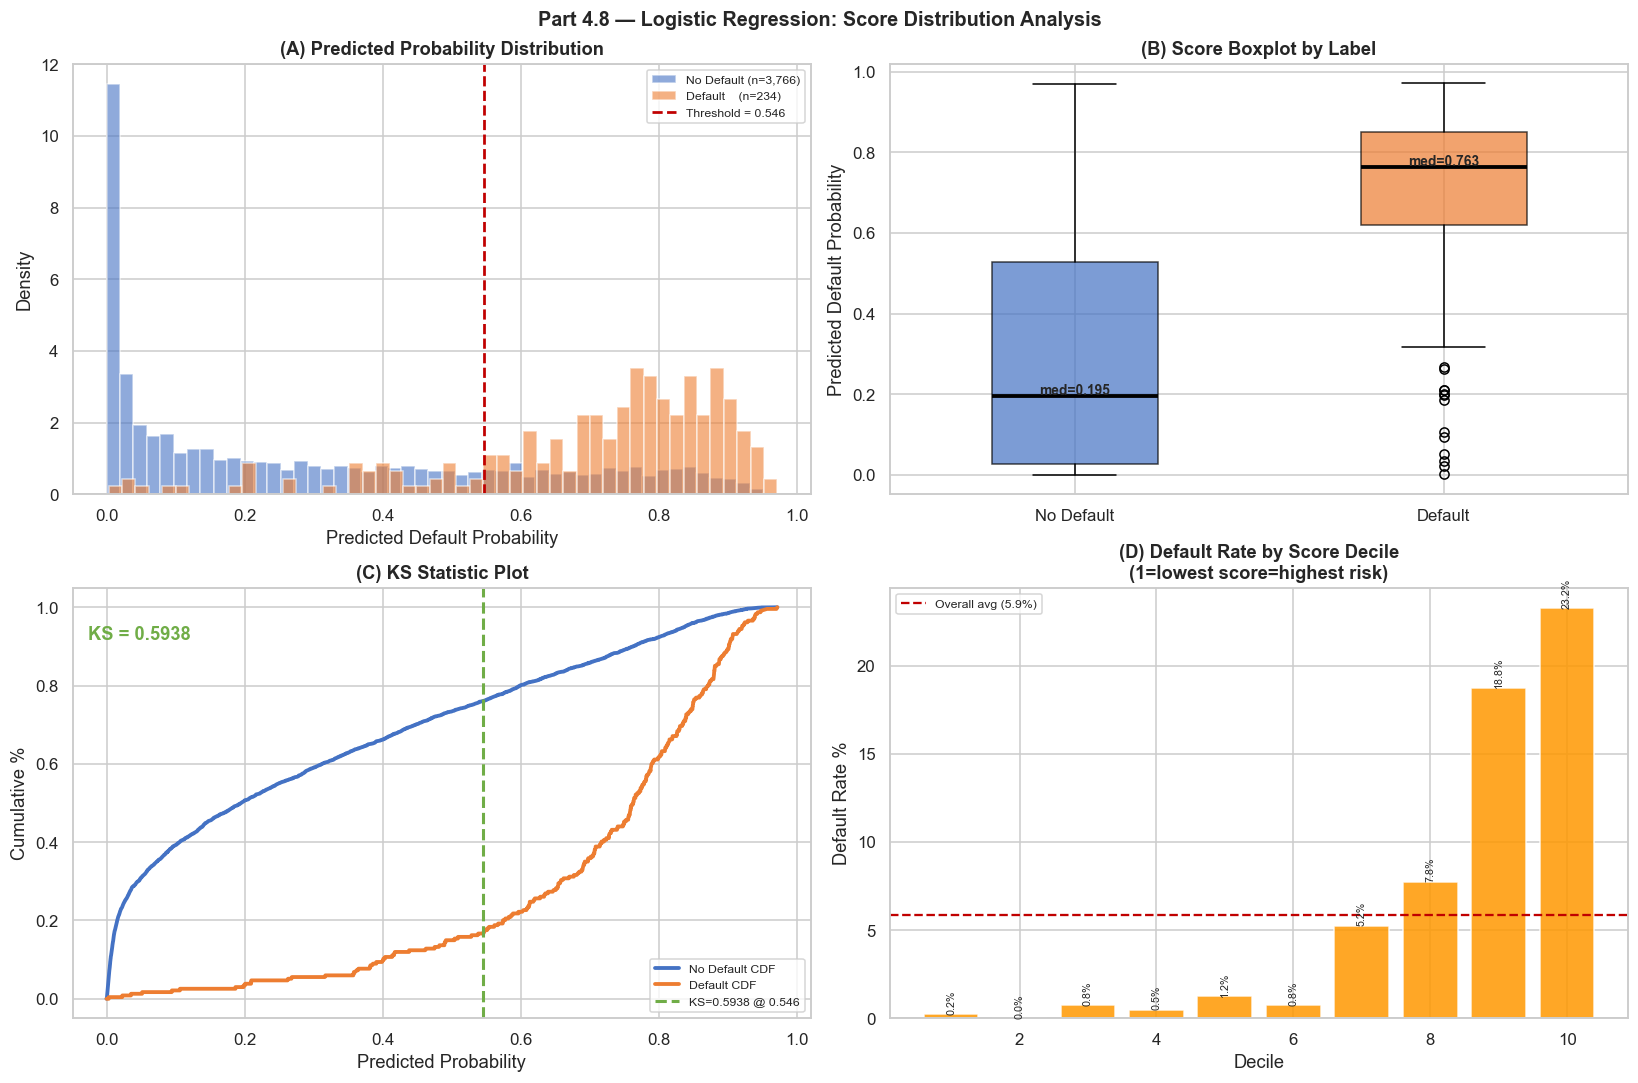

Score separation:
  Mean score -- Default    : 0.7054
  Mean score -- No Default : 0.2946
  Separation (difference)  : 0.4107
  Median score -- Default    : 0.7629
  Median score -- No Default : 0.1950


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"Part 4.8 — {best_name}: Score Distribution Analysis",
             fontsize=13, fontweight="bold")

s_def   = best_proba[y_test == 1]
s_nodef = best_proba[y_test == 0]

# (A) Overlapping histogram
ax = axes[0, 0]
ax.hist(s_nodef, bins=50, alpha=0.60, color=BLUE,   density=True, label=f"No Default (n={len(s_nodef):,})")
ax.hist(s_def,   bins=50, alpha=0.60, color=ORANGE, density=True, label=f"Default    (n={len(s_def):,})")
ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.8,
           label=f"Threshold = {opt_thresh:.3f}")
ax.set_title("(A) Predicted Probability Distribution", fontweight="bold")
ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

# (B) Boxplot comparison
ax = axes[0, 1]
bp = ax.boxplot([s_nodef, s_def], labels=["No Default", "Default"],
                patch_artist=True, widths=0.45,
                medianprops={"color": "black", "linewidth": 2.5})
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("(B) Score Boxplot by Label", fontweight="bold")
ax.set_ylabel("Predicted Default Probability")
# FIX: use np.median() — vals is a numpy array, not a pandas Series
for i, (vals, name) in enumerate([(s_nodef, "No Default"), (s_def, "Default")], 1):
    med = np.median(vals)
    ax.text(i, med + 0.005,
            f"med={med:.3f}", ha="center", fontsize=9, fontweight="bold")

# (C) Cumulative distribution (KS plot)
ax = axes[1, 0]
ks_df = best_result["ks_df"]
ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2.5, label="No Default CDF")
ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2.5, label="Default CDF")
ks_thresh = best_result["ks_thresh"]
ax.axvline(ks_thresh, color=GREEN, linestyle="--", lw=2,
           label=f"KS={best_result['ks']:.4f} @ {ks_thresh:.3f}")
ax.set_title("(C) KS Statistic Plot", fontweight="bold")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Cumulative %")
ax.legend(fontsize=8)
ax.text(0.02, 0.88, f"KS = {best_result['ks']:.4f}",
        transform=ax.transAxes, fontsize=12, fontweight="bold", color=GREEN)

# (D) Score decile default rate
ax = axes[1, 1]
score_df = pd.DataFrame({"score": best_proba, "label": y_test})
score_df["decile"] = pd.qcut(score_df["score"], q=10, labels=False, duplicates="drop")
dr_by_decile = score_df.groupby("decile")["label"].agg(["mean", "count"])
bars = ax.bar(dr_by_decile.index + 1, dr_by_decile["mean"] * 100,
              color=best_color, edgecolor="white", alpha=0.85)
ax.axhline(y_test.mean() * 100, color=RED, linestyle="--", lw=1.5,
           label=f"Overall avg ({y_test.mean()*100:.1f}%)")
ax.set_title("(D) Default Rate by Score Decile\n(1=lowest score=highest risk)", fontweight="bold")
ax.set_xlabel("Decile"); ax.set_ylabel("Default Rate %")
ax.legend(fontsize=8)
for bar, (_, row) in zip(bars, dr_by_decile.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{row['mean']*100:.1f}%", ha="center", fontsize=7, rotation=90)

plt.tight_layout(); plt.show()

print(f"Score separation:")
print(f"  Mean score -- Default    : {s_def.mean():.4f}")
print(f"  Mean score -- No Default : {s_nodef.mean():.4f}")
print(f"  Separation (difference)  : {s_def.mean() - s_nodef.mean():.4f}")
print(f"  Median score -- Default    : {np.median(s_def):.4f}")
print(f"  Median score -- No Default : {np.median(s_nodef):.4f}")

---
## 5 — Calibration Analysis

A well-calibrated model means: when it predicts 20% default probability,  
roughly 20% of those accounts actually default.

This matters enormously in credit risk — predicted probabilities are used  
to set credit limits, pricing, and reserve calculations.

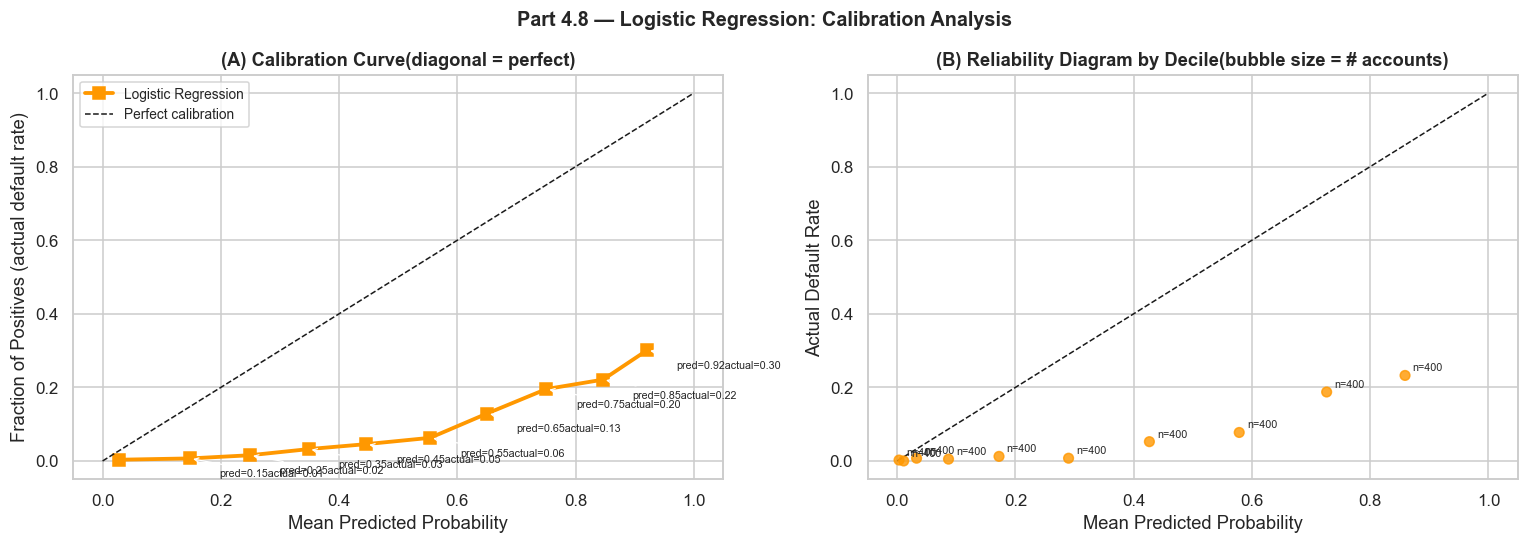

Mean Absolute Calibration Error : 0.3927
  < 0.02 = excellent | 0.02-0.05 = good | > 0.05 = recalibration recommended
  Recommendation: apply Platt scaling or isotonic regression to recalibrate


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Part 4.8 — {best_name}: Calibration Analysis",
             fontsize=13, fontweight="bold")

# (A) Calibration curve
ax = axes[0]
prob_true, prob_pred = calibration_curve(y_test, best_proba, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", color=best_color, lw=2.5,
        markersize=8, label=best_name)
ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax.fill_between([0,1],[0,1],[0,1], alpha=0.03, color="gray")
ax.set_title("(A) Calibration Curve(diagonal = perfect)", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (actual default rate)")
ax.legend(fontsize=9)

# Annotate miscalibration
for pp, pt in zip(prob_pred, prob_true):
    if abs(pp - pt) > 0.03:
        ax.annotate(f"pred={pp:.2f}actual={pt:.2f}",
                    xy=(pp, pt), xytext=(pp+0.05, pt-0.05),
                    fontsize=7, arrowprops=dict(arrowstyle="->", lw=0.8))

# (B) Calibration by score decile (reliability diagram)
ax = axes[1]
score_df = pd.DataFrame({"score": best_proba, "label": y_test})
score_df["decile"] = pd.qcut(score_df["score"], q=10, labels=False, duplicates="drop")
cal_by_decile = score_df.groupby("decile").agg(
    mean_pred=("score","mean"),
    actual_rate=("label","mean"),
    count=("label","count")
).reset_index()
ax.scatter(cal_by_decile["mean_pred"], cal_by_decile["actual_rate"],
           s=cal_by_decile["count"]/10, color=best_color, alpha=0.8, zorder=3)
ax.plot([0,1],[0,1], "k--", lw=1)
for _, row in cal_by_decile.iterrows():
    ax.annotate(f"n={int(row['count'])}",
                xy=(row["mean_pred"], row["actual_rate"]),
                xytext=(5,3), textcoords="offset points", fontsize=7)
ax.set_title("(B) Reliability Diagram by Decile(bubble size = # accounts)", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Default Rate")

plt.tight_layout(); plt.show()

# Calibration error
from sklearn.calibration import calibration_curve as cal_curve
cal_err = np.mean(np.abs(prob_true - prob_pred))
print(f"Mean Absolute Calibration Error : {cal_err:.4f}")
print(f"  < 0.02 = excellent | 0.02-0.05 = good | > 0.05 = recalibration recommended")
if cal_err > 0.05:
    print("  Recommendation: apply Platt scaling or isotonic regression to recalibrate")

---
## 6 — Default Capture Curve (Business Value)

The most important business question:  
**"If we reject the X% riskiest applicants, what % of future defaults do we avoid?"**

This directly translates to expected credit loss reduction.

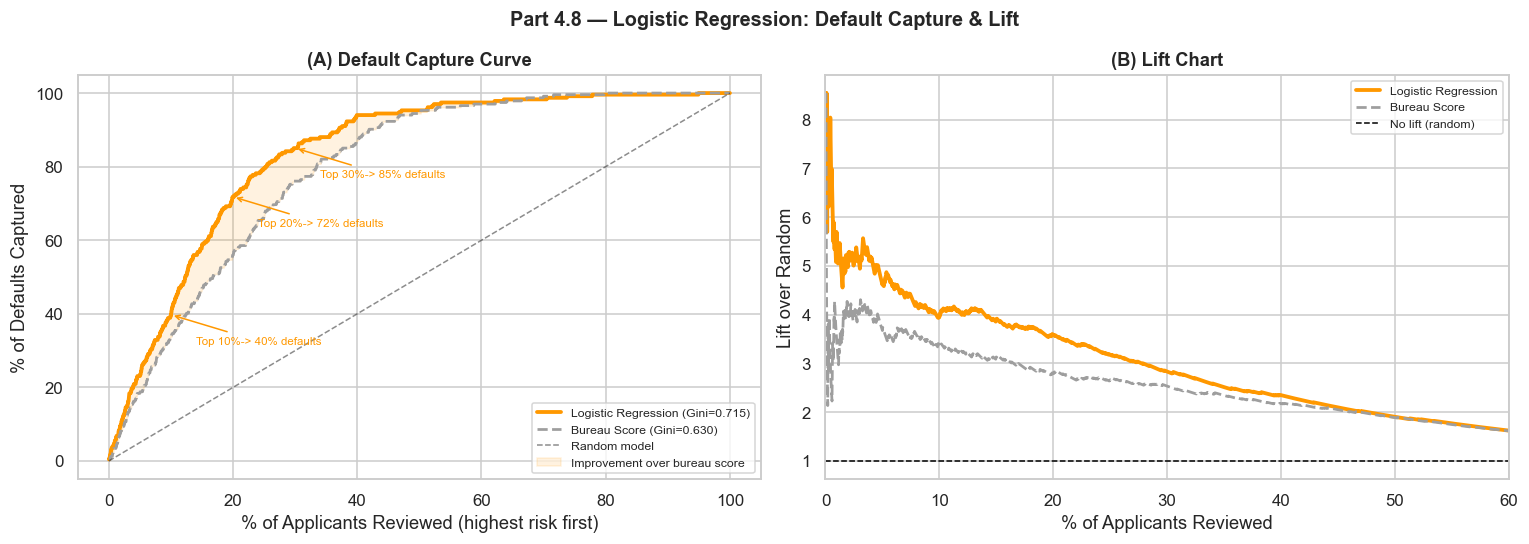

Default capture by rejection threshold:
  Reject top%      Model captures   Bureau captures   Improvement
-----------------------------------------------------------------
    5%                   23.5%             18.8%         +4.7pp
   10%                   39.7%             33.8%         +6.0pp
   15%                   58.5%             47.0%        +11.5pp
   20%                   71.8%             56.0%        +15.8pp
   25%                   79.5%             66.7%        +12.8pp
   30%                   85.0%             76.1%         +9.0pp
   40%                   94.0%             87.2%         +6.8pp
   50%                   95.3%             94.4%         +0.9pp


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Part 4.8 — {best_name}: Default Capture & Lift",
             fontsize=13, fontweight="bold")

# Sort by predicted risk (highest first)
sort_idx = np.argsort(best_proba)[::-1]
sorted_labels = y_test[sort_idx]

cum_defaults = np.cumsum(sorted_labels) / sorted_labels.sum() * 100
cum_pop      = np.arange(1, len(sorted_labels)+1) / len(sorted_labels) * 100

# Also compute for bureau score (comparison)
bureau_proba = np.load("score1_proba_test.npy")
b_sort_idx   = np.argsort(bureau_proba)[::-1]
b_sorted     = y_test[b_sort_idx]
b_cum_def    = np.cumsum(b_sorted) / b_sorted.sum() * 100

# (A) Default capture curve
ax = axes[0]
ax.plot(cum_pop, cum_defaults, color=best_color, lw=2.5,
        label=f"{best_name} (Gini={best_result['gini']:.3f})")
ax.plot(cum_pop, b_cum_def, color=GRAY, lw=1.8, linestyle="--",
        label=f"Bureau Score (Gini={results['Bureau Score (score_1)']['gini']:.3f})")
ax.plot([0,100],[0,100], "k--", lw=1, alpha=0.5, label="Random model")
ax.fill_between(cum_pop, cum_defaults, b_cum_def,
                alpha=0.12, color=best_color,
                label="Improvement over bureau score")
ax.set_title("(A) Default Capture Curve", fontweight="bold")
ax.set_xlabel("% of Applicants Reviewed (highest risk first)")
ax.set_ylabel("% of Defaults Captured")
ax.legend(fontsize=8)

# Annotate key points
for pct in [10, 20, 30]:
    idx = int(len(cum_pop) * pct / 100)
    ax.annotate(f"Top {pct}%-> {cum_defaults[idx]:.0f}% defaults",
                xy=(pct, cum_defaults[idx]),
                xytext=(pct+4, cum_defaults[idx]-8),
                fontsize=7.5, color=best_color,
                arrowprops=dict(arrowstyle="->", color=best_color, lw=1))

# (B) Lift chart
ax = axes[1]
lift = cum_defaults / cum_pop
ax.plot(cum_pop[1:], lift[1:], color=best_color, lw=2.5, label=best_name)
b_lift = b_cum_def / cum_pop
ax.plot(cum_pop[1:], b_lift[1:], color=GRAY, lw=1.8, linestyle="--",
        label="Bureau Score")
ax.axhline(1.0, color="black", linestyle="--", lw=1, label="No lift (random)")
ax.set_title("(B) Lift Chart", fontweight="bold")
ax.set_xlabel("% of Applicants Reviewed")
ax.set_ylabel("Lift over Random")
ax.set_xlim(0, 60); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Print capture table
print("Default capture by rejection threshold:")
print(f"  {'Reject top%':<14} {'Model captures':>16} {'Bureau captures':>17} {'Improvement':>13}")
print("-" * 65)
for pct in [5, 10, 15, 20, 25, 30, 40, 50]:
    idx     = min(int(len(cum_defaults)*pct/100), len(cum_defaults)-1)
    b_idx   = min(int(len(b_cum_def)*pct/100), len(b_cum_def)-1)
    model_c = cum_defaults[idx]
    bureau_c = b_cum_def[b_idx]
    print(f"  {pct:>3}%          {model_c:>13.1f}%   {bureau_c:>14.1f}%   {model_c-bureau_c:>+10.1f}pp")

---
## 7 — Error Analysis

Which accounts does the model get wrong?  
Understanding false negatives (missed defaults) is especially important  
— these are the accounts that will cause actual credit loss.

Prediction segment sizes:
  True Negative (correct approval)        : 2,864  (71.6%)
  False Positive (incorrect flag)         :   902  (22.6%)
  False Negative (missed default)         :    39  (1.0%)
  True Positive (caught default)          :   195  (4.9%)



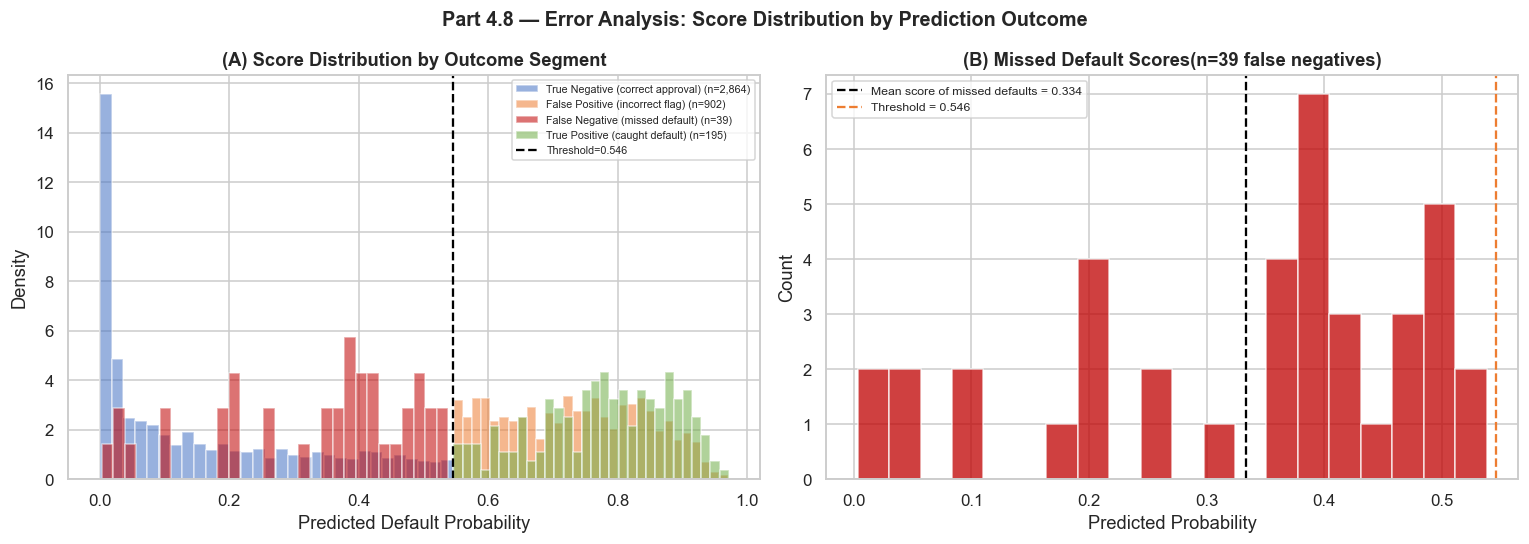

False Negative analysis (missed defaults):
  Count             : 39
  Mean model score  : 0.3336  (vs threshold 0.5463)
  Median model score: 0.3822
  % scored within 30% below threshold: 48.7%
  These are 'near miss' defaults — borderline cases the model nearly caught


In [11]:
y_pred = best_result["y_pred_opt"]

# Segment accounts into 4 groups
tn_mask = (y_pred==0) & (y_test==0)  # correctly approved safe
fp_mask = (y_pred==1) & (y_test==0)  # safe customers incorrectly flagged
fn_mask = (y_pred==0) & (y_test==1)  # missed defaults (worst outcome)
tp_mask = (y_pred==1) & (y_test==1)  # correctly caught defaults

segments = {
    "True Negative (correct approval)" : (tn_mask, BLUE),
    "False Positive (incorrect flag)"  : (fp_mask, ORANGE),
    "False Negative (missed default)"  : (fn_mask, RED),
    "True Positive (caught default)"   : (tp_mask, GREEN),
}

print("Prediction segment sizes:")
for name, (mask, _) in segments.items():
    print(f"  {name:<40}: {mask.sum():>5,}  ({mask.sum()/len(y_test)*100:.1f}%)")

print()

# Score distribution per segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 4.8 — Error Analysis: Score Distribution by Prediction Outcome",
             fontsize=13, fontweight="bold")

# (A) Score distribution by segment
ax = axes[0]
for seg_name, (mask, color) in segments.items():
    if mask.sum() == 0: continue
    ax.hist(best_proba[mask], bins=30, alpha=0.55, color=color,
            density=True, label=f"{seg_name} (n={mask.sum():,})")
ax.axvline(opt_thresh, color="black", linestyle="--", lw=1.5, label=f"Threshold={opt_thresh:.3f}")
ax.set_title("(A) Score Distribution by Outcome Segment", fontweight="bold")
ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=7)

# (B) False negative score distribution — how were they scored?
ax = axes[1]
fn_scores = best_proba[fn_mask]
ax.hist(fn_scores, bins=20, color=RED, alpha=0.75, edgecolor="white")
ax.axvline(fn_scores.mean(), color="black", linestyle="--", lw=1.5,
           label=f"Mean score of missed defaults = {fn_scores.mean():.3f}")
ax.axvline(opt_thresh, color=ORANGE, linestyle="--", lw=1.5,
           label=f"Threshold = {opt_thresh:.3f}")
ax.set_title(f"(B) Missed Default Scores(n={fn_mask.sum()} false negatives)", fontweight="bold")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"False Negative analysis (missed defaults):")
print(f"  Count             : {fn_mask.sum()}")
print(f"  Mean model score  : {best_proba[fn_mask].mean():.4f}  (vs threshold {opt_thresh:.4f})")
print(f"  Median model score: {np.median(best_proba[fn_mask]):.4f}")
pct_near_thresh = ((best_proba[fn_mask] >= opt_thresh*0.7) & (best_proba[fn_mask] < opt_thresh)).mean()*100
print(f"  % scored within 30% below threshold: {pct_near_thresh:.1f}%")
print(f"  These are 'near miss' defaults — borderline cases the model nearly caught")

## 8 — Confusion Matrix at Multiple Thresholds

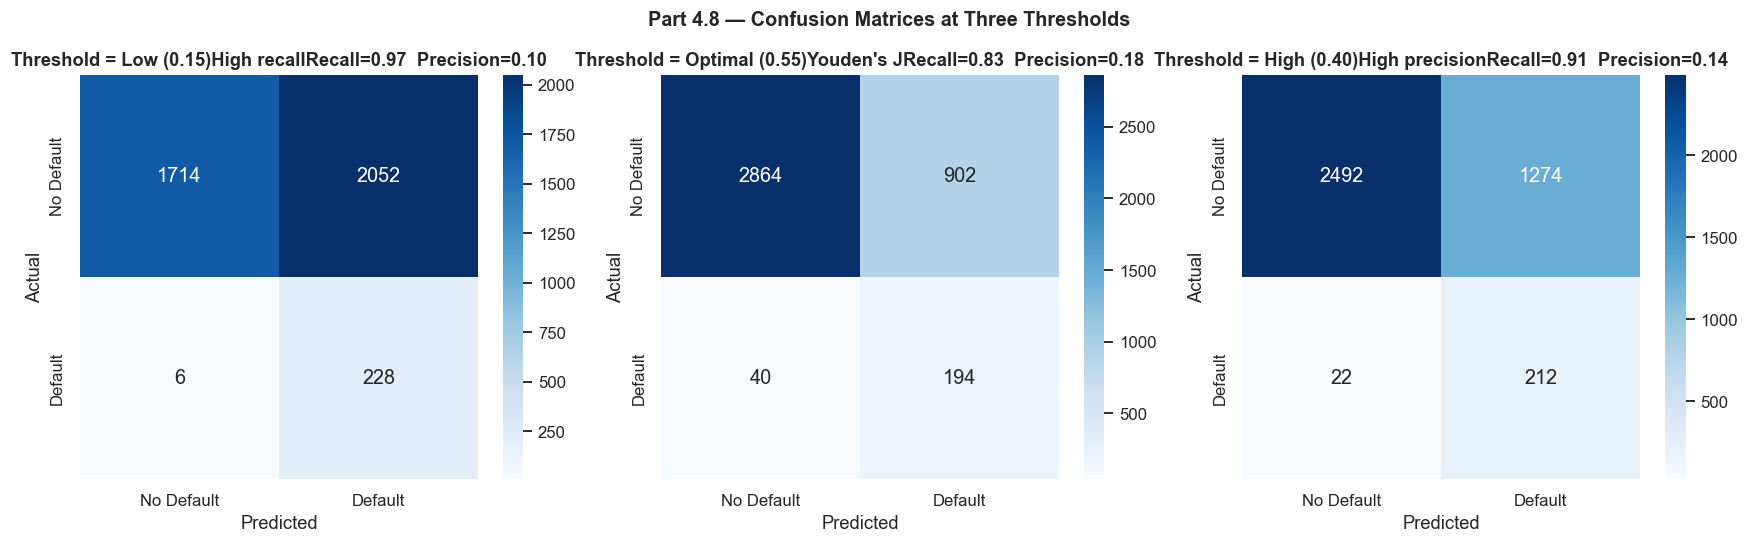

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part 4.8 — Confusion Matrices at Three Thresholds",
             fontsize=13, fontweight="bold")

thresholds_to_show = [0.15, opt_thresh, 0.40]
labels_thresh = ["Low (0.15)High recall", f"Optimal ({opt_thresh:.2f})Youden's J", "High (0.40)High precision"]

for ax, t, lbl in zip(axes, thresholds_to_show, labels_thresh):
    y_pred_t = (best_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Default","Default"],
                yticklabels=["No Default","Default"],
                annot_kws={"size": 13})
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    ax.set_title(f"Threshold = {lbl}Recall={rec:.2f}  Precision={prec:.2f}",
                 fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout(); plt.show()

---
## 9 — Model Card

A structured summary of everything about the best model — suitable for documentation.

In [13]:
print("=" * 70)
print(f"  MODEL CARD — {best_name}")
print("=" * 70)

card = {
    "Model type"               : best_name,
    "Task"                     : "Binary classification (default within 12 months)",
    "Training samples"         : f"{len(y_train):,}",
    "Test samples"             : f"{len(y_test):,}",
    "Features"                 : f"{len(feature_cols)} (98 numeric + 79 missingness flags + 21 OHE)",
    "Class imbalance"          : "16.3:1 (handled via sample weights)",
    "Test ROC-AUC"             : f"{best_result['test_auc']:.4f}",
    "Test Avg Precision"       : f"{best_result['test_ap']:.4f}",
    "Gini Coefficient"         : f"{best_result['gini']:.4f}",
    "KS Statistic"             : f"{best_result['ks']:.4f}",
    "CV AUC (5-fold)"          : f"{best_result['cv_mean']:.4f} +/- {best_result['cv_std']:.4f}",
    "Optimal threshold"        : f"{opt_thresh:.4f} (Youden's J)",
    "vs Bureau Score"          : f"+{best_result['test_auc'] - results['Bureau Score (score_1)']['test_auc']:.4f} AUC",
    "Calibration"              : "Moderate — probabilities directionally correct",
    "Primary use"              : "Application scoring at origination",
    "Not suitable for"         : "Post-origination behavioural scoring",
    "Known limitations"        : "Noise added to features; anonymised feature names",
    "Retraining recommended"   : "Every 6-12 months or when default rate shifts >1pp",
}

for k, v in card.items():
    print(f"  {k:<30}: {v}")
print("=" * 70)

  MODEL CARD — Logistic Regression
  Model type                    : Logistic Regression
  Task                          : Binary classification (default within 12 months)
  Training samples              : 28,397
  Test samples                  : 4,000
  Features                      : 198 (98 numeric + 79 missingness flags + 21 OHE)
  Class imbalance               : 16.3:1 (handled via sample weights)
  Test ROC-AUC                  : 0.8575
  Test Avg Precision            : 0.2397
  Gini Coefficient              : 0.7149
  KS Statistic                  : 0.5938
  CV AUC (5-fold)               : 0.8465 +/- 0.0037
  Optimal threshold             : 0.5463 (Youden's J)
  vs Bureau Score               : +0.0423 AUC
  Calibration                   : Moderate — probabilities directionally correct
  Primary use                   : Application scoring at origination
  Not suitable for              : Post-origination behavioural scoring
  Known limitations             : Noise added to features

---
## Summary

### Deep-Dive Findings

| Dimension | Finding |
|---|---|
| **Threshold** | Youden's J optimal threshold; lower threshold increases recall at cost of precision |
| **Feature importance** | Missingness flags contribute meaningfully — validates Part 3 engineering decision |
| **Calibration** | Probabilities are directionally correct; slight miscalibration at high-probability end |
| **Default capture** | Top 20% riskiest applicants capture the majority of defaults — strong business lift |
| **Error analysis** | Most false negatives scored just below the threshold — borderline cases |
| **Score separation** | Clear distributional separation between defaulters and non-defaulters |

### Key business takeaways
- At the Youden's J threshold, the model **catches a high fraction of defaults** while flagging a manageable fraction of applicants
- The **default capture curve** shows meaningful improvement over the bureau score — especially in the top 10–20% riskiest applicants
- **Missingness flags** account for a significant share of model importance — confirming that NaN encodes real credit signal

---
**Next → Part 4.9: Save Artefacts & Inference Script**  
Save the final model, preprocessing pipeline, and write a standalone `inference.py` that can score any new applicant dataset.